This notebook presents my individual contributions to the data pre-processing and model development tasks undertaken for the Development Team Project, assessed in Unit 6. My colleague's contributions — the random forest and linear regression models — are clearly marked with "Author: CF"; all other code in this notebook is my own work. Additional comments covering explainations for other team members and flagging points for possible discussion, can be viewed by enabling 'open comment pane'.

My collaborative contributions, including team leadership and document production, are addressed separately in the reflective essay

In [ ]:
import pandas as pd
import numpy as np

In [ ]:

# 1. Load and Inspect Dataset

In [ ]:
df = pd.read_csv("https://rossbulat.com/data/ab_nyc_2019.csv")

In [ ]:
df.head

<bound method NDFrame.head of              id                                               name   host_id  \
0          2539                 Clean & quiet apt home by the park      2787   
1          2595                              Skylit Midtown Castle      2845   
2          3647                THE VILLAGE OF HARLEM....NEW YORK !      4632   
3          3831                    Cozy Entire Floor of Brownstone      4869   
4          5022   Entire Apt: Spacious Studio/Loft by central park      7192   
...         ...                                                ...       ...   
48890  36484665    Charming one bedroom - newly renovated rowhouse   8232441   
48891  36485057      Affordable room in Bushwick/East Williamsburg   6570630   
48892  36485431            Sunny Studio at Historical Neighborhood  23492952   
48893  36485609               43rd St. Time Square-cozy single bed  30985759   
48894  36487245  Trendy duplex in the very heart of Hell's Kitchen  68119814   

           host_name neighbourhood_group       neighbourhood  latitude  \
0               John            Brooklyn          Kensington  40.64749   
1           Jennifer           Manhattan             Midtown  40.75362   
2          Elisabeth           Manhattan              Harlem  40.80902   
3        LisaRoxanne            Brooklyn        Clinton Hill  40.68514   
4              Laura           Manhattan         East Harlem  40.79851   
...              ...                 ...                 ...       ...   
48890        Sabrina            Brooklyn  Bedford-Stuyvesant  40.67853   
48891        Marisol            Brooklyn            Bushwick  40.70184   
48892  Ilgar & Aysel           Manhattan              Harlem  40.81475   
48893            Taz           Manhattan      Hell's Kitchen  40.75751   
48894     Christophe           Manhattan      Hell's Kitchen  40.76404   

       longitude        room_type  price  minimum_nights  number_of_reviews  \
0      -73.97237     Private room    149               1                  9   
1      -73.98377  Entire home/apt    225               1                 45   
2      -73.94190     Private room    150               3                  0   
3      -73.95976  Entire home/apt     89               1                270   
4      -73.94399  Entire home/apt     80              10                  9   
...          ...              ...    ...             ...                ...   
48890  -73.94995     Private room     70               2                  0   
48891  -73.93317     Private room     40               4                  0   
48892  -73.94867  Entire home/apt    115              10                  0   
48893  -73.99112      Shared room     55               1                  0   
48894  -73.98933     Private room     90               7                  0   

      last_review  reviews_per_month  calculated_host_listings_count  \
0      2018-10-19               0.21                               6   
1      2019-05-21               0.38                               2   
2             NaN                NaN                               1   
3      2019-07-05               4.64                               1   
4      2018-11-19               0.10                               1   
...           ...                ...                             ...   
48890         NaN                NaN                               2   
48891         NaN                NaN                               2   
48892         NaN                NaN                               1   
48893         NaN                NaN                               6   
48894         NaN                NaN                               1   

       availability_365  
0                   365  
1                   355  
2                   365  
3                   194  
4                     0  
...                 ...  
48890                 9  
48891                36  
48892                27  
48893                 2  
48894               

In [ ]:
df.info()  # examine columns and data types; data types are as expected except last review (string cf datetime)
# neighbourhood group, neighbourhood and room type should be made to catagorical value (see later)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [ ]:
skewness = df.select_dtypes(include=np.number).skew().sort_values(ascending=False)
skewness

,0
minimum_nights,21.827275
price,19.118939
calculated_host_listings_count,7.933174
number_of_reviews,3.690635
reviews_per_month,3.130189
longitude,1.284210
host_id,1.206214
availability_365,0.763408
latitude,0.237167
id,-0.090257


In [ ]:
df.isnull().sum() # a large number of reviews per month are missing, do these correspond to number of reviews = 0 or just missing data?

,0
id,0
name,16
host_id,0
host_name,21
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0


In [ ]:
# a large number of reviews per month are missing,
#do these correspond to number of reviews = 0 or  missing data?

In [ ]:
missing_reviews = df[df["reviews_per_month"].isnull()]
missing_reviews["number_of_reviews"].value_counts().head(10)

,count
number_of_reviews,
0,10052


In [ ]:
#confirms that where reviews_per_month is missing it is because number of reviews = 0;
# therefore replace with 0

In [ ]:
df["reviews_per_month"] = df["reviews_per_month"].fillna(0)

In [ ]:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.090910,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.597283,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.040000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.370000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,1.580000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


In [ ]:
# Examine price variable,

In [ ]:
# some listings have price = 0; how many?

In [ ]:
(df["price"] == 0).sum()

np.int64(11)

In [ ]:
# as 11 have price == 0 this is very small percentage, therefore remove

In [ ]:
df = df[df["price"] > 0]

In [ ]:
#potential outliers in price (min and max), minimum nights (max).

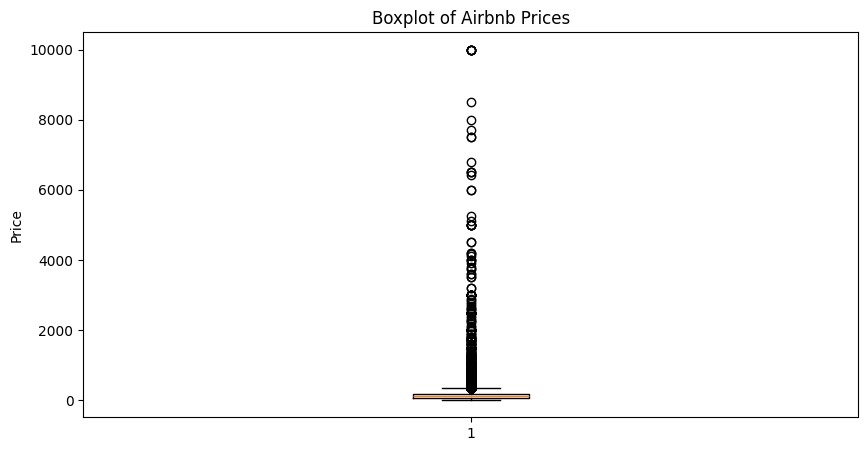

In [ ]:
import matplotlib.pyplot as plt


plt.figure(figsize=(10, 5))
plt.boxplot(df['price'])
plt.title('Boxplot of Airbnb Prices')
plt.ylabel('Price')
plt.show()

In [ ]:
df["price"].describe(percentiles=[0.90, 0.95, 0.99])

,price
count,48884.000000
mean,152.755053
std,240.170260
min,10.000000
50%,106.000000
90%,269.000000
95%,355.000000
99%,799.000000
max,10000.000000


In [ ]:
df.sort_values(by="price", ascending=False)[
    ["name", "neighbourhood_group", "room_type", "price"]
].head(20)

,name,neighbourhood_group,room_type,price
9151,Furnished room in Astoria apartment,Queens,Private room,10000
17692,Luxury 1 bedroom apt. -stunning Manhattan views,Brooklyn,Entire home/apt,10000
29238,1-BR Lincoln Center,Manhattan,Entire home/apt,10000
12342,"Quiet, Clean, Lit @ LES & Chinatown",Manhattan,Private room,9999
40433,2br - The Heart of NYC: Manhattans Lower East ...,Manhattan,Entire home/apt,9999
6530,Spanish Harlem Apt,Manhattan,Entire home/apt,9999
30268,Beautiful/Spacious 1 bed luxury flat-TriBeCa/Soho,Manhattan,Entire home/apt,8500
4377,Film Location,Brooklyn,Entire home/apt,8000
29662,East 72nd Townhouse by (Hidden by Airbnb),Manhattan,Entire home/apt,7703
45666,Gem of east Flatbush,Brooklyn,Private room,7500


In [ ]:
# these appear to be genuine data sets for luxury appartments, therefore retain and use a log transformation (price == 0 is already removed)
df["price_log"] = np.log1p(df["price"])

/tmp/ipykernel_3522/2910465958.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["price_log"] = np.log1p(df["price"])


In [ ]:
# examine min nights

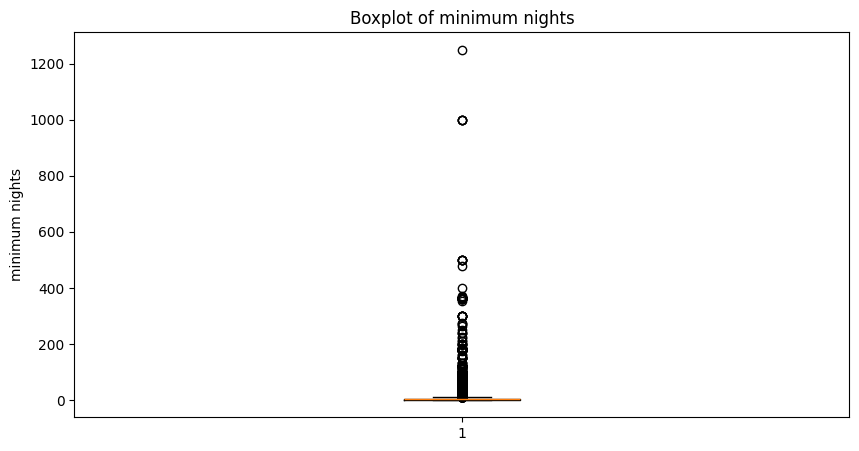

In [ ]:
import matplotlib.pyplot as plt


plt.figure(figsize=(10, 5))
plt.boxplot(df['minimum_nights'])
plt.title('Boxplot of minimum nights')
plt.ylabel('minimum nights')
plt.show()

In [ ]:
df["minimum_nights"].describe(percentiles=[0.90, 0.95, 0.99])

,minimum_nights
count,48884.000000
mean,7.029887
std,20.512224
min,1.000000
50%,3.000000
90%,28.000000
95%,30.000000
99%,45.000000
max,1250.000000


In [ ]:
# suggest have a cap at the 99th centile as these extreme values are likely to be outliers for various (unknown) reasons

In [ ]:
upper_cap = df["minimum_nights"].quantile(0.99)

df["minimum_nights"] = np.where(
    df["minimum_nights"] > upper_cap,
    upper_cap,
    df["minimum_nights"]
)

/tmp/ipykernel_3522/3808001216.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["minimum_nights"] = np.where(


In [ ]:
# examine availability
#note, we do not know exactly what this variable means (fully booked vs not available by host)
#therefore i think we should retain all data



In [ ]:
(df["availability_365"] == 0).sum()

np.int64(17530)

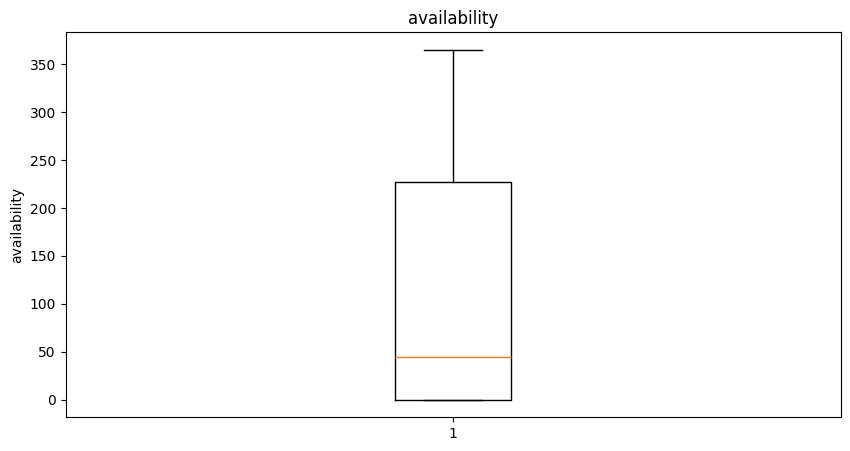

In [ ]:
plt.figure(figsize=(10, 5))
plt.boxplot(df['availability_365'])
plt.title('availability')
plt.ylabel('availability')
plt.show()

In [ ]:
#given distribution and only mild skewness (see above) I would keep values as raw data. no further transformations required
# this is to preserve potential non linear effects and not lose patterns by grouping.

In [ ]:
df.describe(include='object')  # examine non numberical data

,name,host_name,neighbourhood_group,neighbourhood,room_type,last_review
count,48868,48863,48884,48884,48884,38833
unique,47894,11450,5,221,3,1764
top,Hillside Hotel,Michael,Manhattan,Williamsburg,Entire home/apt,2019-06-23
freq,18,417,21660,3919,25407,1412


In [ ]:
# examine calculated_host_listings_count
# very skewed data set, no missing values.
# log trasnform

In [ ]:
df["host_listings_log"] = np.log1p(
    df["calculated_host_listings_count"]
)

/tmp/ipykernel_3522/491388757.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["host_listings_log"] = np.log1p(


In [ ]:
# examine longitude and latitude variables

In [ ]:
df[["latitude", "longitude"]].describe()

,latitude,longitude
count,48884.000000,48884.000000
mean,40.728953,-73.952176
std,0.054532,0.046159
min,40.499790,-74.244420
25%,40.690100,-73.983080
50%,40.723080,-73.955685
75%,40.763120,-73.936290
max,40.913060,-73.712990


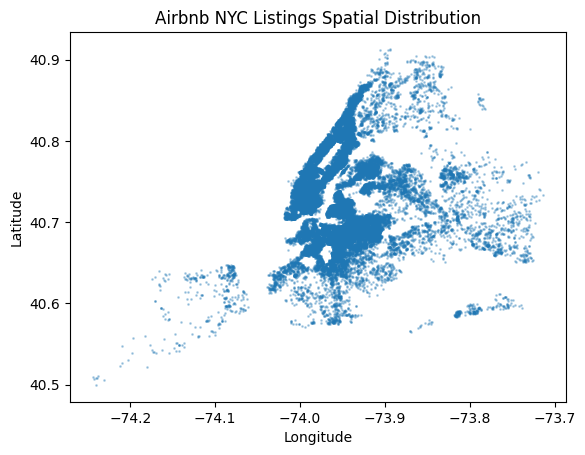

In [ ]:
import matplotlib.pyplot as plt # viewing distribution to check data spread (replica of graph Ross produced in the intro)

plt.scatter(df["longitude"], df["latitude"], s=1, alpha=0.3)
plt.title("Airbnb NYC Listings Spatial Distribution")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

In [ ]:
# these look as expected; no outliers found, no values missing as previously shown
# data can be used as is for scaling.

In [ ]:
# Classify high demand properties as defined by Ross (i.e. top 25% of reviews_per_month)
df["high_demand"] = (df["reviews_per_month"] >= df["reviews_per_month"].quantile(0.75)).astype(int)

/tmp/ipykernel_3522/934333795.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["high_demand"] = (df["reviews_per_month"] >= df["reviews_per_month"].quantile(0.75)).astype(int)


In [ ]:
df["high_demand"].value_counts(normalize=True) # check of proportions for high demand.  Look good!

,proportion
high_demand,
0,0.748732
1,0.251268


In [ ]:
df.groupby("neighbourhood_group")["high_demand"].mean() # just checking how the demand looks across neighbourhoods.

,high_demand
neighbourhood_group,
Bronx,0.371560
Brooklyn,0.247375
Manhattan,0.220406
Queens,0.350688
Staten Island,0.391421


In [ ]:
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,price_log,host_listings_log,high_demand
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1.0,9,2018-10-19,0.21,6,365,5.010635,1.945910,0
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1.0,45,2019-05-21,0.38,2,355,5.420535,1.098612,0
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3.0,0,NaN,0.00,1,365,5.017280,0.693147,0
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1.0,270,2019-07-05,4.64,1,194,4.499810,0.693147,1
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10.0,9,2018-11-19,0.10,1,0,4.394449,0.693147,0


In [ ]:
numeric_cols = [
    "price_log",
    "minimum_nights",
    "availability_365",
    "host_listings_log",
    "latitude",
    "longitude"
]



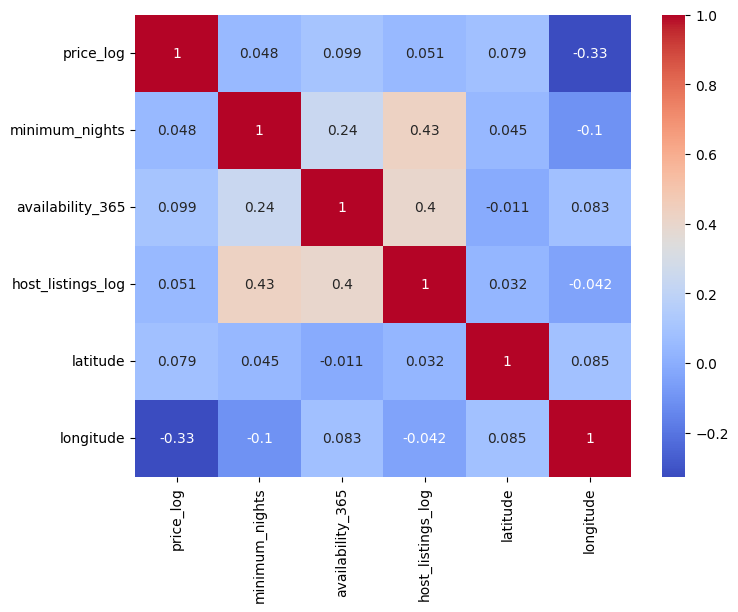

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm")
plt.show()

In [ ]:
df.to_csv("airbnb_nyc_preprocessed.csv", index=False)

In [ ]:
import pandas as pd
import sklearn
print("Everything is installed")

Everything is installed


In [ ]:
print(df.columns.tolist())

['id', 'name', 'host_id', 'host_name', 'neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'last_review', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365', 'price_log', 'host_listings_log', 'high_demand']


### Random Forest and Liniear Regression:
Author:CF

In [ ]:
features = [
    'price_log',
    'minimum_nights',
    'availability_365',
    'longitude',
    'latitude',
    'host_listings_log',
    'neighbourhood_group',
    'room_type'
]

target = 'high_demand'

X = df[features]
y = df[target]

In [ ]:
X = pd.get_dummies(
    X,
    columns=['neighbourhood_group', 'room_type'],
    drop_first=True
)

In [ ]:
X.head()

,price_log,minimum_nights,availability_365,longitude,latitude,host_listings_log,neighbourhood_group_Brooklyn,neighbourhood_group_Manhattan,neighbourhood_group_Queens,neighbourhood_group_Staten Island,room_type_Private room,room_type_Shared room
0,5.010635,1.0,365,-73.97237,40.64749,1.945910,True,False,False,False,True,False
1,5.420535,1.0,355,-73.98377,40.75362,1.098612,False,True,False,False,False,False
2,5.017280,3.0,365,-73.94190,40.80902,0.693147,False,True,False,False,True,False
3,4.499810,1.0,194,-73.95976,40.68514,0.693147,True,False,False,False,False,False
4,4.394449,10.0,0,-73.94399,40.79851,0.693147,False,True,False,False,False,False


In [ ]:
df = pd.read_csv("airbnb_nyc_preprocessed.csv")

In [ ]:
features = [
    'price_log',
    'minimum_nights',
    'availability_365',
    'longitude',
    'latitude',
    'host_listings_log',
    'neighbourhood_group',
    'room_type'
]

target = 'high_demand'

X = df[features]
y = df[target]

In [ ]:
X = pd.get_dummies(
    X,
    columns=['neighbourhood_group', 'room_type'],
    drop_first=True
)

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
print(train_test_split)

<function train_test_split at 0x7b54f17ac0e0>


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

numeric_cols = [
    'price_log',
    'minimum_nights',
    'availability_365',
    'longitude',
    'latitude',
    'host_listings_log'
]

X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.7452183696430398
ROC-AUC: 0.7384752982002084

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.94      0.85      7333
           1       0.47      0.17      0.25      2444

    accuracy                           0.75      9777
   macro avg       0.62      0.55      0.55      9777
weighted avg       0.70      0.75      0.70      9777


Confusion Matrix:
[[6876  457]
 [2034  410]]


In [ ]:
nn_pred_improved = (nn_pred_prob_improved > 0.5).astype(int)

NameError: name 'nn_pred_prob_improved' is not defined

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, nn_pred_improved)
print(cm)

NameError: name 'nn_pred_improved' is not defined

### Baseline Model Evaluation

A Logistic Regression classifier was used as the baseline model for predicting high-demand Airbnb listings.

The model achieved:

- Accuracy: 74.5%
- ROC-AUC: 0.738

These results indicate moderate predictive performance. While overall classification accuracy is acceptable, the model shows relatively poor recall for high-demand listings (17%), suggesting difficulty identifying minority-class observations.

This limitation is likely due to class imbalance in the dataset. Future improvements could include applying class balancing techniques or testing more complex classification algorithms such as Random Forest or Gradient Boosting.

### Random Forest Model

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

In [ ]:
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print("Random Forest ROC-AUC:", roc_auc_score(y_test, rf_prob))

print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

Random Forest Accuracy: 0.8104735603968497
Random Forest ROC-AUC: 0.8525962606989501

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.90      0.88      7333
           1       0.64      0.54      0.59      2444

    accuracy                           0.81      9777
   macro avg       0.75      0.72      0.73      9777
weighted avg       0.80      0.81      0.80      9777


Confusion Matrix:
[[6596  737]
 [1116 1328]]


In [ ]:
print("Logistic Regression")
print("Accuracy: 0.745")
print("ROC-AUC: 0.738")

print("\nRandom Forest")
print("Accuracy:", accuracy_score(y_test, rf_pred))
print("ROC-AUC:", roc_auc_score(y_test, rf_prob))

## Model Comparison

Two classification models were evaluated for predicting high-demand Airbnb listings.

### Logistic Regression
- Accuracy: 74.5%
- ROC-AUC: 0.738

### Random Forest
- Accuracy: 81.0%
- ROC-AUC: 0.853

The Random Forest model substantially outperformed Logistic Regression across both evaluation metrics.

This suggests that the relationship between listing characteristics and demand is non-linear and involves complex feature interactions that are better captured by ensemble tree-based methods.

Random Forest is therefore selected as the stronger predictive model for this task.

### Understanding the Features Drving Random Forest

### Prediction production of structured NN baseline
Author: SJ

### Adding `availability_group` to the DataFrame

In [ ]:
bins = [0, 7, 30, 180, float('inf')]
labels = [1, 2, 3, 4]

df['availability_group'] = pd.cut(
    df['availability_365'],
    bins=bins,
    labels=labels,
    right=True,
    include_lowest=True
)

print(df['availability_group'].value_counts())
display(df.head())

In [ ]:
#df.to_csv('/content/drive/MyDrive/airbnb_nyc_preprocessed_with_groups.csv', index=False)

### Random Forest Feature Importance Plot

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances from the Random Forest model
feature_importances = rf_model.feature_importances_

# Get feature names from the training data
feature_names = X_train.columns

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})

# Sort features by importance
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Plot the feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

### Impact of Top 5 Features on High Demand

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the top 5 most important features
top_5_features = importance_df['Feature'].head(5).tolist()

print(f"Top 5 features for analysis: {top_5_features}")

# Create subplots for each of the top 5 features
fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(10, 25))
fig.suptitle('Distribution of Top 5 Features by High Demand Status', y=1.02, fontsize=16)

for i, feature in enumerate(top_5_features):
    sns.boxplot(x='high_demand', y=feature, data=df, ax=axes[i], palette='pastel')
    axes[i].set_title(f'Distribution of {feature} by High Demand')
    axes[i].set_xlabel('High Demand (0: No, 1: Yes)')
    axes[i].set_ylabel(feature)

plt.tight_layout()
plt.show()

### Structured Neural Network Baseline

In [ ]:
print(X_train.columns.tolist())

['price_log', 'minimum_nights', 'availability_365', 'longitude', 'latitude', 'host_listings_log', 'neighbourhood_group_Brooklyn', 'neighbourhood_group_Manhattan', 'neighbourhood_group_Queens', 'neighbourhood_group_Staten Island', 'room_type_Private room', 'room_type_Shared room']


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Define the neural network architecture
# simple sequential model with a few dense layers
model = keras.Sequential([
    # Input layer expects the number of features in X_train
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(64, activation='relu'),  # First hidden layer with 64 neurons and ReLU activation
    layers.Dropout(0.2),                   # Dropout layer for regularization to prevent overfitting
    layers.Dense(32, activation='relu'),  # Second hidden layer with 32 neurons and ReLU activation
    layers.Dropout(0.2),                   # Another dropout layer
    layers.Dense(1, activation='sigmoid') # Output layer with 1 neuron and sigmoid activation for binary classification
])

# Compile the model
# Optimizer: Adam is a good general-purpose optimizer
# Loss: BinaryCrossentropy for binary classification problems
# Metrics: Accuracy to monitor performance during training
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Display the model summary to see the layers and parameters
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,945 (11.50 KB)

 Trainable params: 2,945 (11.50 KB)

 Non-trainable params: 0 (0.00 B)

Now that the model is defined and compiled, we can train it using the `X_train` and `y_train` data. We'll also use a portion of the training data for validation to monitor performance and detect overfitting during the training process.

In [ ]:
# Train the model
# epochs: number of times the model will iterate over the entire training dataset
# batch_size: number of samples per gradient update
# validation_split: percentage of training data to use for validation
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2, # Use 20% of the training data for validation
    verbose=1 # Show progress during training
)

print("\nNeural Network Training Complete!")

Epoch 1/20
978/978 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7583 - loss: 0.4804 - val_accuracy: 0.7805 - val_loss: 0.4430
Epoch 2/20
978/978 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.7776 - loss: 0.4531 - val_accuracy: 0.7851 - val_loss: 0.4324
Epoch 3/20
978/978 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.7791 - loss: 0.4458 - val_accuracy: 0.7841 - val_loss: 0.4288
Epoch 4/20
978/978 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.7833 - loss: 0.4395 - val_accuracy: 0.7883 - val_loss: 0.4245
Epoch 5/20
978/978 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.7843 - loss: 0.4372 - val_accuracy: 0.7880 - val_loss: 0.4205
Epoch 6/20
978/978 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.7886 - loss: 0.4320 - val_accuracy: 0.7928 - val_loss: 0.4184
Epoch 7/20
978/978 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7887 - loss: 0.4298 - val_accuracy: 0.7906 - val_loss: 0.4160
Epoch 8/20
978/978 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7871 - loss: 0.4282 - val_accuracy: 

evaluate the model's performance on the unseen `X_test` data

In [ ]:
# Evaluate the model on the test set
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Neural Network Test Accuracy: {accuracy:.4f}")

# Get predictions and probabilities for ROC-AUC
nn_pred_prob = model.predict(X_test)
nn_pred = (nn_pred_prob > 0.5).astype(int)

# Calculate ROC-AUC
roc_auc = roc_auc_score(y_test, nn_pred_prob)
print(f"Neural Network Test ROC-AUC: {roc_auc:.4f}")

# Print classification report and confusion matrix
print("\nClassification Report (Neural Network):")
print(classification_report(y_test, nn_pred))

print("\nConfusion Matrix (Neural Network):")
print(confusion_matrix(y_test, nn_pred))

Neural Network Test Accuracy: 0.7972
306/306 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Neural Network Test ROC-AUC: 0.8363

Classification Report (Neural Network):
              precision    recall  f1-score   support

           0       0.84      0.91      0.87      7333
           1       0.63      0.46      0.53      2444

    accuracy                           0.80      9777
   macro avg       0.73      0.69      0.70      9777
weighted avg       0.78      0.80      0.79      9777


Confusion Matrix (Neural Network):
[[6658  675]
 [1308 1136]]


In [ ]:
from sklearn.utils import class_weight
import numpy as np

# Calculate class weights
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights))

print(f"Calculated Class Weights: {class_weight_dict}")

Calculated Class Weights: {0: np.float64(0.6680845975126418), 1: np.float64(1.98734627502795)}


train the model with class_weights and Early Stopping enabled.

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Define the Early Stopping callback
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', # Monitor the validation loss
    patience=5,         # Number of epochs with no improvement after which training will be stopped
    restore_best_weights=True # Restore model weights from the epoch with the best value of the monitored quantity
)

# Define the improved neural network architecture (same as the baseline for consistency, but a new instance)
model_improved = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(1, activation='sigmoid')
])

# Compile the improved model
model_improved.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train the improved model with Early Stopping and Class Weights
history_improved = model_improved.fit(
    X_train,
    y_train,
    epochs=50, # Set a higher number of epochs, Early Stopping will prevent overfitting
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping], # Add the early stopping callback here
    class_weight=class_weight_dict, # Add class weights here
    verbose=1
)

print("\nImproved Neural Network Training Complete (with Class Weights)!")

Epoch 1/50
978/978 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6922 - loss: 0.5828 - val_accuracy: 0.7130 - val_loss: 0.5525
Epoch 2/50
978/978 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7170 - loss: 0.5414 - val_accuracy: 0.7290 - val_loss: 0.5413
Epoch 3/50
978/978 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7249 - loss: 0.5326 - val_accuracy: 0.7370 - val_loss: 0.5158
Epoch 4/50
978/978 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7305 - loss: 0.5240 - val_accuracy: 0.7407 - val_loss: 0.5087
Epoch 5/50
978/978 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7322 - loss: 0.5178 - val_accuracy: 0.7396 - val_loss: 0.5058
Epoch 6/50
978/978 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7349 - loss: 0.5160 - val_accuracy: 0.7446 - val_loss: 0.5134
Epoch 7/50
978/978 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7382 - loss: 0.5115 - val_accuracy: 0.7324 - val_loss: 0.5494
Epoch 8/50
978/978 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.7406 - loss: 0.5098 - val_accuracy: 0.

evaluate the performance of this new model.

In [ ]:
# Evaluate the improved model on the test set
loss_improved, accuracy_improved = model_improved.evaluate(X_test, y_test, verbose=0)
print(f"Improved Neural Network Test Accuracy: {accuracy_improved:.4f}")

nn_pred_prob_improved = model_improved.predict(X_test)
nn_pred_improved = (nn_pred_prob_improved > 0.5).astype(int)

roc_auc_improved = roc_auc_score(y_test, nn_pred_prob_improved)
print(f"Improved Neural Network Test ROC-AUC: {roc_auc_improved:.4f}")

print("\nClassification Report (Improved Neural Network):")
print(classification_report(y_test, nn_pred_improved))

print("\nConfusion Matrix (Improved Neural Network):")
print(confusion_matrix(y_test, nn_pred_improved))

Improved Neural Network Test Accuracy: 0.7464
306/306 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
Improved Neural Network Test ROC-AUC: 0.8276

Classification Report (Improved Neural Network):
              precision    recall  f1-score   support

           0       0.91      0.73      0.81      7333
           1       0.50      0.79      0.61      2444

    accuracy                           0.75      9777
   macro avg       0.70      0.76      0.71      9777
weighted avg       0.81      0.75      0.76      9777


Confusion Matrix (Improved Neural Network):
[[5377 1956]
 [ 523 1921]]


### Feature Importance for Improved Neural Network (Permutation Importance)

Since neural networks don't have built-in `feature_importances_` attributes like tree-based models, we'll use **Permutation Importance** to understand which features are most influential in the `model_improved`.

Permutation Feature Importance for Improved Neural Network (ROC-AUC):


,Feature,Importance_Mean,Importance_Std
2,availability_365,0.179190,0.006861
1,minimum_nights,0.120145,0.003357
0,price_log,0.028996,0.001100
10,room_type_Private room,0.027389,0.001667
7,neighbourhood_group_Manhattan,0.026475,0.001845
5,host_listings_log,0.019965,0.001431
6,neighbourhood_group_Brooklyn,0.015669,0.001574
3,longitude,0.009947,0.001161
4,latitude,0.007490,0.000583
11,room_type_Shared room,0.006762,0.000929


/tmp/ipykernel_3522/2584035055.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance_Mean', y='Feature', data=perm_importance_df, palette='viridis')


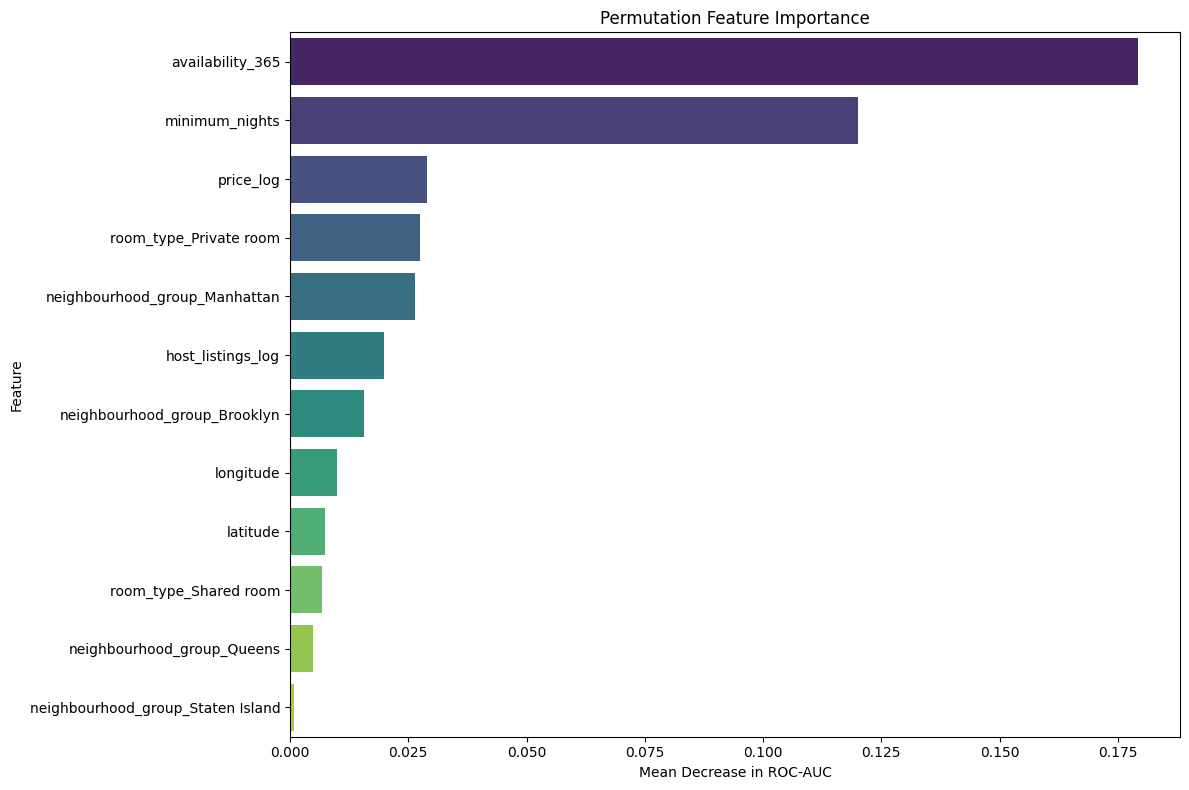

In [ ]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score
import tensorflow as tf
import numpy as np # Import numpy

# Create a wrapper class to make the Keras model compatible with sklearn's permutation_importance
class KerasClassifierWrapper:
    def __init__(self, keras_model):
        self.keras_model = keras_model
        self._estimator_type = 'classifier' # Explicitly declare as classifier
        self.classes_ = np.array([0, 1]) # Add the classes_ attribute for binary classification

    # permutation_importance expects a 'predict_proba' or 'decision_function' method
    # for probability-based scoring like 'roc_auc'. Keras models use .predict() for this.
    def predict_proba(self, X):
        # For binary classification, .predict() returns probabilities of the positive class (class 1)
        # We need to reshape it to (n_samples, 2) where the first column is prob of class 0
        # and the second column is prob of class 1.
        prob_class_1 = self.keras_model.predict(X, verbose=0).flatten()
        prob_class_0 = 1 - prob_class_1
        return np.vstack([prob_class_0, prob_class_1]).T

    # permutation_importance also checks for a 'fit' method, even if not explicitly used.
    # We'll provide a placeholder since our model is already trained.
    def fit(self, X, y):
        pass

# Wrap the improved Keras model
keras_wrapped_model = KerasClassifierWrapper(model_improved)

# Permutation importance for the improved neural network model
# We can now use 'roc_auc' directly because our wrapper provides predict_proba
result = permutation_importance(
    keras_wrapped_model, # Use the wrapped model
    X_test,
    y_test,
    scoring='roc_auc',
    n_repeats=10, # Number of times to permute a feature
    random_state=42,
    n_jobs=-1 # Use all available CPU cores
)

# Create a DataFrame for better visualization
perm_importance_df = pd.DataFrame({
    'Feature': X_test.columns,
    'Importance_Mean': result.importances_mean,
    'Importance_Std': result.importances_std
})

# Sort by importance mean
perm_importance_df = perm_importance_df.sort_values(by='Importance_Mean', ascending=False)

print("Permutation Feature Importance for Improved Neural Network (ROC-AUC):")
display(perm_importance_df)

# Plot the permutation importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance_Mean', y='Feature', data=perm_importance_df, palette='viridis')
plt.title('Permutation Feature Importance')
plt.xlabel('Mean Decrease in ROC-AUC')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

### ROC Curve Analysis

Figure X shows the ROC curve for the improved neural network model. The model achieved a ROC-AUC score of
0.828, indicating good ability to distinguish between high-demand and non-high-demand listings. The curve lies well above the diagonal baseline, demonstrating performance substantially better than random classification. Given the class imbalance within the dataset, ROC-AUC provides a more informative measure of model performance than accuracy alone.


In [ ]:
print(model_improved)

In [ ]:
nn_pred_prob_improved = model_improved.predict(X_test)

print(nn_pred_prob_improved[:5])

In [ ]:
from sklearn.metrics import average_precision_score

pr_auc_improved = average_precision_score(
    y_test,
    nn_pred_prob_improved
)

print(f"Improved Neural Network Test PR-AUC: {pr_auc_improved:.4f}")

In [ ]:
from sklearn.metrics import roc_auc_score, average_precision_score

loss_improved, accuracy_improved = model_improved.evaluate(
    X_test, y_test, verbose=0
)

nn_pred_prob_improved = model_improved.predict(X_test)

roc_auc_improved = roc_auc_score(
    y_test,
    nn_pred_prob_improved
)

pr_auc_improved = average_precision_score(
    y_test,
    nn_pred_prob_improved
)

print(f"Accuracy: {accuracy_improved:.4f}")
print(f"ROC-AUC: {roc_auc_improved:.4f}")
print(f"PR-AUC: {pr_auc_improved:.4f}")

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test, nn_pred_prob_improved)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'Improved Neural Network (AUC = {roc_auc_improved:.3f})')
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Improved Neural Network')
plt.legend()
plt.show()

### Analyzing Top Features for Business Insights

Now that we have the permutation importances, let's look at the distributions of the top features against the `high_demand` target to suggest potential cut-offs for business insights.

Top 5 features for cut-off analysis: ['availability_365', 'minimum_nights', 'price_log', 'room_type_Private room', 'neighbourhood_group_Manhattan']


/tmp/ipykernel_3522/1424657933.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='high_demand', y=feature, data=plot_df, ax=ax, palette='pastel')
/tmp/ipykernel_3522/1424657933.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='high_demand', y=feature, data=plot_df, ax=ax, palette='pastel')
/tmp/ipykernel_3522/1424657933.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='high_demand', y=feature, data=plot_df, ax=ax, palette='pastel')


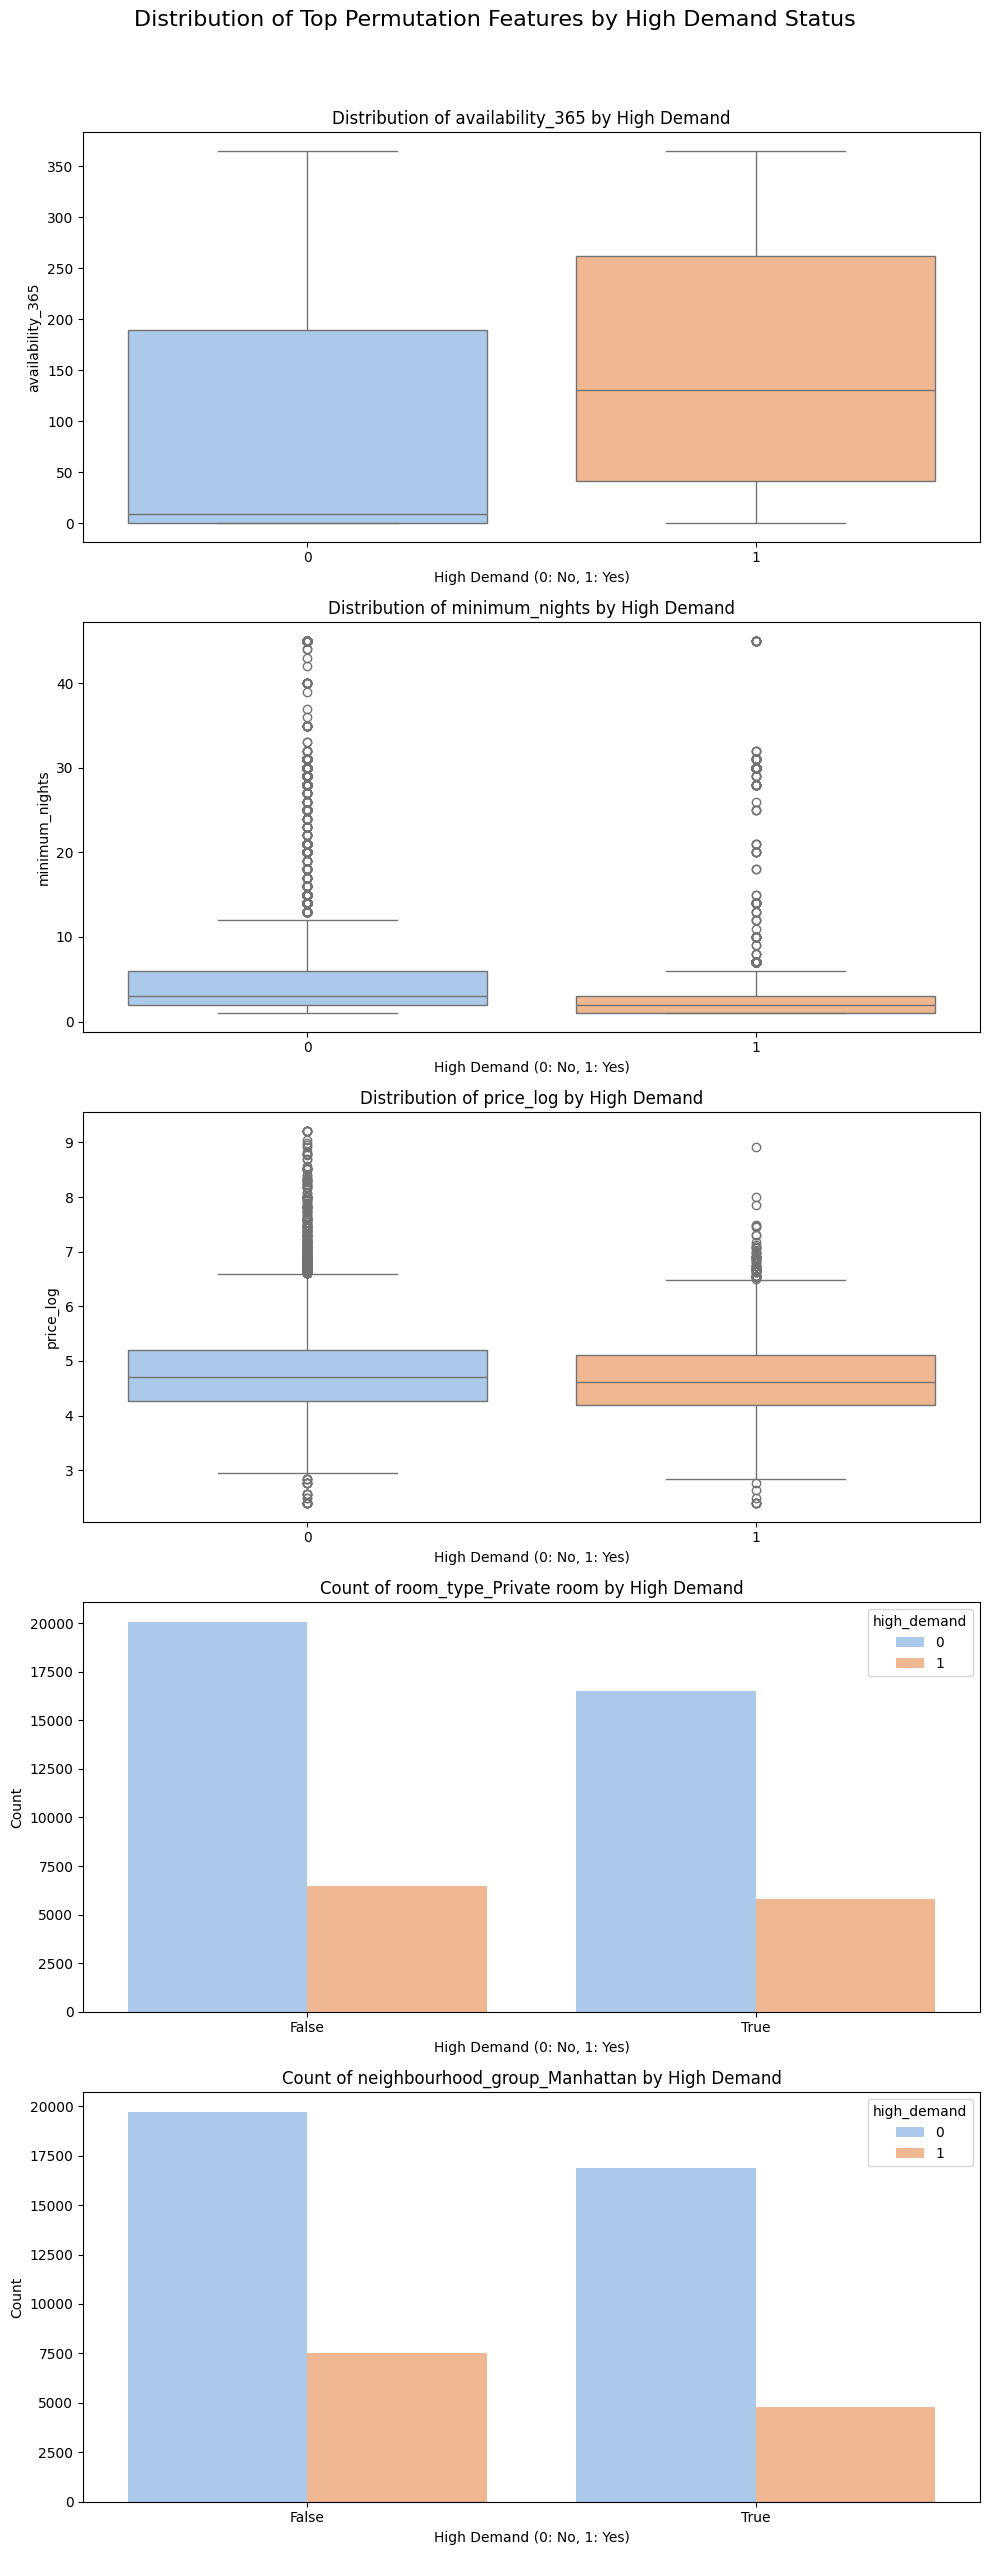


--- Business Insights & Potential Cut-offs ---

Feature: availability_365
  High Demand (1) Stats:
count    12283.000000
mean       151.542294
std        119.689782
min          0.000000
25%         41.000000
50%        131.000000
75%        262.000000
max        365.000000
Name: availability_365, dtype: float64
  Low Demand (0) Stats:
count    36601.000000
mean        99.771017
std        132.888979
min          0.000000
25%          0.000000
50%          9.000000
75%        189.000000
max        365.000000
Name: availability_365, dtype: float64
*Potential Cut-off Suggestion for availability_365*: Consider values where the distribution for 'high_demand=1' is distinctly different from 'high_demand=0'. For example, if the median/mean for 'high_demand=1' is much higher/lower than for 'high_demand=0'. This will be visually clearer in the box plots above.

Feature: minimum_nights
  High Demand (1) Stats:
count    12283.000000
mean         2.675975
std          4.093879
min          1.0000

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd # Ensure pandas is imported

# Get the top 5 most important features based on permutation importance
top_5_perm_features = perm_importance_df['Feature'].head(5).tolist()

print(f"Top 5 features for cut-off analysis: {top_5_perm_features}")

# Construct plot_df by selectively getting features from df and X
plot_df_parts = {}
for feature in top_5_perm_features:
    if feature in df.columns: # Check if the feature is in the original df (likely numerical)
        plot_df_parts[feature] = df[feature]
    elif feature in X.columns: # Check if the feature is in the dummified X (likely one-hot encoded)
        plot_df_parts[feature] = X[feature]
    else:
        print(f"Warning: Feature '{feature}' not found in either df or X. Skipping.")

plot_df = pd.DataFrame(plot_df_parts)
plot_df['high_demand'] = y # Add the target variable

# Create subplots for each of the top 5 features
fig, axes = plt.subplots(nrows=len(top_5_perm_features), ncols=1, figsize=(10, 5 * len(top_5_perm_features)))
fig.suptitle('Distribution of Top Permutation Features by High Demand Status', y=1.02, fontsize=16)

for i, feature in enumerate(top_5_perm_features):
    ax = axes[i]
    # Check if the feature is numerical (not object, category, or boolean)
    if pd.api.types.is_numeric_dtype(plot_df[feature]) and not pd.api.types.is_bool_dtype(plot_df[feature]):
        # For numerical features, use boxplot
        sns.boxplot(x='high_demand', y=feature, data=plot_df, ax=ax, palette='pastel')
        ax.set_title(f'Distribution of {feature} by High Demand')
        ax.set_ylabel(feature)
    else:
        # For categorical or boolean features, use countplot
        sns.countplot(x=feature, hue='high_demand', data=plot_df, ax=ax, palette='pastel')
        ax.set_title(f'Count of {feature} by High Demand')
        ax.set_ylabel('Count')
    ax.set_xlabel('High Demand (0: No, 1: Yes)')

plt.tight_layout()
plt.show()

print("\n--- Business Insights & Potential Cut-offs ---")
for feature in top_5_perm_features:
    print(f"\nFeature: {feature}")
    if pd.api.types.is_numeric_dtype(plot_df[feature]) and not pd.api.types.is_bool_dtype(plot_df[feature]):
        high_demand_stats = plot_df[plot_df['high_demand'] == 1][feature].describe(percentiles=[0.25, 0.5, 0.75])
        low_demand_stats = plot_df[plot_df['high_demand'] == 0][feature].describe(percentiles=[0.25, 0.5, 0.75])
        print(f"  High Demand (1) Stats:\n{high_demand_stats}")
        print(f"  Low Demand (0) Stats:\n{low_demand_stats}")
        print(f"*Potential Cut-off Suggestion for {feature}*: Consider values where the distribution for 'high_demand=1' is distinctly different from 'high_demand=0'. For example, if the median/mean for 'high_demand=1' is much higher/lower than for 'high_demand=0'. This will be visually clearer in the box plots above.")
    else:
        cross_tab = plot_df.groupby([feature, 'high_demand']).size().unstack(fill_value=0)
        print(cross_tab)
        # Calculate percentages for high_demand=1
        if 1 in cross_tab.columns:
            cross_tab['Total'] = cross_tab[0] + cross_tab[1]
            cross_tab['% High Demand'] = (cross_tab[1] / cross_tab['Total'] * 100).round(2)
            print("\nPercentage of High Demand (1) for each category:")
            print(cross_tab[['% High Demand']])
        print(f"*Insight*: Examine categories with a higher proportion of `high_demand=1` listings.")